###### DSM500 - MSc Thesis: Investigating the Performance and Reliability of Deep-Learning Flood Segmentation Under Varying Flood Extent Using Sentinel-1 SAR Imagery
###### 10 August 2026
###### Archie Hulse
###### Student Number: 250410903
##### Notebook 4: 
#                                               04 - <u>Model Implimentation & Training<u/>
--------------------------------

#### <u>Contents:</u>
###### *(Hyperlinks to sections of this report)*

#### [Go to Section 1](#1) - Import & Load

[1.1](#1.1) Notebook Introduction

[1.2](#1.2) Imports & configuration

[1.3](#1.3) Project paths

[1.4](#1.4) Load experimental metadata

[1.5](#1.5) Verify train/validation/test/Bolivia split

[1.6](#1.6) Load Sentinel-1 + LabelHand + JRCWaterHand

#### [Go to Section 2](#2) - Check & Calculate Flood Extent (%)

[2.1](#2.1) Scene inspection

[2.2](#2.2) Spatial alignment verification

[2.3](#2.3) JRC-adjusted flood extent calculation

#### [Go to Section 3](#3) - Normalisation of Training Data

[3.1](#3.1) Training-set normalisation statistics

[3.2](#3.2) Normalisation test on example scene

#### [Go to Section 4](#4) - PyTorch Dataset and DataLoaders

[4.1](#4.1) Configuration & Dataset creation

[4.2](#4.2) Test & Verify

#### [Go to Section 5](#5) - U-Net Model

[5.1](#5.1) U-Net Architecture

[5.2](#5.2) Model Checks

[5.3](#5.3) U-Net training

[5.4](#5.4) U-Net Test Evaluation

[5.5](#5.5) U-Net Bolivia holdout evaluation

[5.6](#5.6) U-Net Results

#### [Go to Section 6](#6) - SegFormer-B0 model

[6.1](#6.1) SegFormer-B0 Architecture

[6.2](#6.2) SegFormer training configuration

[6.3](#6.3) SegFormer-B0 Model Training

[6.4](#6.4) SegFormer-B0 Test Evaluation

[6.5](#6.5) SegFormer-B0 Bolivia holdout evaluation

[6.6](#6.6) SegFormer-B0 Results

------------------------------

###### 1
###### 1.1
### Section 1.1 - Notebook Introduction:

This notebook trains the two deep-learning segmentation models used in this study:

1. U-Net — convolutional neural network baseline
2. SegFormer — transformer-based segmentation model

Both models are trained using the same dataset splits, preprocessing,
augmentation strategy, optimisation procedure, loss function, and
evaluation protocol wherever technically possible.

The purpose of this notebook is to produce reproducible trained models
for subsequent inference and analysis.

The primary experimental variable, flood extent (%), is not used as an
input feature to the models. It is retained in the Overview Data so that model
performance can later be analysed as a function of flood extent.

No test-set information or the Bolivia hold-out flood event is used during training or model selection.

--------------------
###### 1.2
### Section 1.2 - Imports & configuration:

In [1]:
# Imports:

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

import torch
from torch.utils.data import Dataset, DataLoader

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.14.0


In [2]:
# Reproducibility & compute device:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Random seed:", SEED)
print("Compute device:", DEVICE)

Random seed: 42
Compute device: mps


--------------
###### 1.3
### Section 1.3 - Project paths

In [ ]:
# Project paths:

def find_project_root():
    """
    Find the project root directory by locating the first
    parent directory containing both Data and Results.
    """
    
    current = Path.cwd().resolve()

    for directory in [current] + list(current.parents):
        if (directory / "Data").exists() and (directory / "Results").exists():
            return directory

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Make sure the repository contains Data/ and Results/ folders."
    )


PROJECT_DIR = find_project_root()

DATA_DIR = PROJECT_DIR / "Data"
RESULTS_DIR = PROJECT_DIR / "Results"
TABLE_DIR = RESULTS_DIR / "tables"

print("Project directory :", PROJECT_DIR)
print("Data directory    :", DATA_DIR)
print("Results directory :", RESULTS_DIR)
print("Tables directory  :", TABLE_DIR)

RESULTS_NEW_DIR = PROJECT_DIR / "results_new"
MODEL_DIR = RESULTS_NEW_DIR / "models"
RESULTS_TABLE_DIR = RESULTS_NEW_DIR / "tables"
FIGURES_DIR = RESULTS_NEW_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("New experiment results directory:", RESULTS_NEW_DIR)
print("New model directory             :", MODEL_DIR)
print("New tables directory            :", RESULTS_TABLE_DIR)
print("New figures directory           :", FIGURES_DIR)


Project directory : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project
Data directory    : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Data
Results directory : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Results
Tables directory  : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Results/tables
New experiment results directory: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new
New model directory             : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models
New tables directory            : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables
New figures directory           : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figure

--------------
###### 1.4
### Section 1.4 - Load experimental metadata

In [4]:
# Load experimental metadata:

METADATA_FILE = TABLE_DIR / "experiment_design_dataTable.csv"
BOLIVIA_METADATA_FILE = TABLE_DIR / "bolivia_holdout_dataTable.csv"

experiment_metadata = pd.read_csv(METADATA_FILE)
bolivia_metadata = pd.read_csv(BOLIVIA_METADATA_FILE)

print("Principal experimental metadata:", experiment_metadata.shape)
print("Bolivia holdout metadata       :", bolivia_metadata.shape)

display(experiment_metadata.head())
display(bolivia_metadata.head())

Principal experimental metadata: (426, 7)
Bolivia holdout metadata       : (15, 12)


,s1_id,split,flood_event,width,height,flood_extent_percent,flood_extent_group
0,Ghana_103272,train,Ghana,512,512,0.600920,0–1%
1,Ghana_24858,train,Ghana,512,512,0.184631,0–1%
2,Ghana_147015,train,Ghana,512,512,1.346588,1–5%
3,Ghana_953791,train,Ghana,512,512,1.057434,1–5%
4,Ghana_154838,train,Ghana,512,512,0.000000,0–1%


,s1_id,s1_filename,label_filename,s1_path,label_path,split,flood_event,width,height,valid_pixels,flood_pixels,flood_extent_percent
0,Bolivia_103757,Bolivia_103757_S1Hand.tif,Bolivia_103757_LabelHand.tif,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,bolivia_holdout,Bolivia,512,512,88077,35362,40.148961
1,Bolivia_129334,Bolivia_129334_S1Hand.tif,Bolivia_129334_LabelHand.tif,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,bolivia_holdout,Bolivia,512,512,237814,156643,65.867863
2,Bolivia_195474,Bolivia_195474_S1Hand.tif,Bolivia_195474_LabelHand.tif,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,bolivia_holdout,Bolivia,512,512,261335,1551,0.593491
3,Bolivia_23014,Bolivia_23014_S1Hand.tif,Bolivia_23014_LabelHand.tif,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,bolivia_holdout,Bolivia,512,512,209479,7780,3.713976
4,Bolivia_233925,Bolivia_233925_S1Hand.tif,Bolivia_233925_LabelHand.tif,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,/Users/archiewilliamhulse/Desktop/Msc Data Sci...,bolivia_holdout,Bolivia,512,512,150537,1,0.000664


--------------
###### 1.5
### Section 1.5 - Verify train/validation/test/Bolivia split

In [5]:
# Verify train / validation / test split:

print("Principal dataset split:")
print(experiment_metadata["split"].value_counts())

print("\nFlood events in principal dataset:")
print(experiment_metadata["flood_event"].value_counts())

print("\nBolivia holdout events:")
print(bolivia_metadata["flood_event"].value_counts())

# Check expected split sizes
assert len(experiment_metadata) == 426

assert (experiment_metadata["split"].value_counts()["train"] == 251)

assert (experiment_metadata["split"].value_counts()["validation"] == 86)

assert (experiment_metadata["split"].value_counts()["test"] == 89)

# Check Bolivia remains completely separate
assert set(experiment_metadata["flood_event"]) .isdisjoint(
    set(bolivia_metadata["flood_event"]))

print("\n✓ Experimental split verified.")
print("✓ 251 training / 86 validation / 89 test.")
print("✓ Bolivia remains completely separate.")

Principal dataset split:
split
train         251
test           89
validation     86
Name: count, dtype: int64

Flood events in principal dataset:
flood_event
USA          69
India        68
Paraguay     67
Ghana        48
Sri-Lanka    42
Mekong       30
Spain        30
Pakistan     28
Somalia      26
Nigeria      18
Name: count, dtype: int64

Bolivia holdout events:
flood_event
Bolivia    15
Name: count, dtype: int64

✓ Experimental split verified.
✓ 251 training / 86 validation / 89 test.
✓ Bolivia remains completely separate.


--------------
###### 1.6
### Section 1.6 - Load Sentinel-1 + LabelHand + JRCWaterHand

In [6]:
# Sen1Floods11 data locations:

SEN1_ROOT = (DATA_DIR/ "Sen1Floods11_raw"/ "v1.1"/ "data")
S1_HAND_DIR = (SEN1_ROOT/ "flood_events"/ "HandLabeled"/ "S1Hand")
LABEL_HAND_DIR = (SEN1_ROOT/ "flood_events"/ "HandLabeled"/ "LabelHand")
JRC_WATER_HAND_DIR = (SEN1_ROOT/ "flood_events"/ "HandLabeled"/ "JRCWaterHand")

print("Sen1Floods11 root:")
print(SEN1_ROOT)
print("\nS1Hand:")
print(S1_HAND_DIR)
print("\nLabelHand:")
print(LABEL_HAND_DIR)
print("\nJRCWaterHand:")
print(JRC_WATER_HAND_DIR)

Sen1Floods11 root:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Data/Sen1Floods11_raw/v1.1/data

S1Hand:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Data/Sen1Floods11_raw/v1.1/data/flood_events/HandLabeled/S1Hand

LabelHand:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Data/Sen1Floods11_raw/v1.1/data/flood_events/HandLabeled/LabelHand

JRCWaterHand:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Data/Sen1Floods11_raw/v1.1/data/flood_events/HandLabeled/JRCWaterHand


In [7]:
# Verify raw data folders:

assert S1_HAND_DIR.exists(), f"S1Hand folder not found: {S1_HAND_DIR}"
assert LABEL_HAND_DIR.exists(), f"LabelHand folder not found: {LABEL_HAND_DIR}"
assert JRC_WATER_HAND_DIR.exists(), (f"JRCWaterHand folder not found: {JRC_WATER_HAND_DIR}")

s1_files = sorted(S1_HAND_DIR.glob("*.tif"))
label_files = sorted(LABEL_HAND_DIR.glob("*.tif"))
jrc_files = sorted(JRC_WATER_HAND_DIR.glob("*.tif"))

print("Folder checks:")
print("S1Hand exists       :", S1_HAND_DIR.exists())
print("LabelHand exists    :", LABEL_HAND_DIR.exists())
print("JRCWaterHand exists :", JRC_WATER_HAND_DIR.exists())

print("\nFile counts:")
print("S1Hand       :", len(s1_files))
print("LabelHand    :", len(label_files))
print("JRCWaterHand :", len(jrc_files))

print("\nExample S1 files:")
for file in s1_files[:5]:
    print(file.name)

print("\nExample LabelHand files:")
for file in label_files[:5]:
    print(file.name)

print("\nExample JRCWaterHand files:")
for file in jrc_files[:5]:
    print(file.name)

Folder checks:
S1Hand exists       : True
LabelHand exists    : True
JRCWaterHand exists : True

File counts:
S1Hand       : 446
LabelHand    : 446
JRCWaterHand : 446

Example S1 files:
Bolivia_103757_S1Hand.tif
Bolivia_129334_S1Hand.tif
Bolivia_195474_S1Hand.tif
Bolivia_23014_S1Hand.tif
Bolivia_233925_S1Hand.tif

Example LabelHand files:
Bolivia_103757_LabelHand.tif
Bolivia_129334_LabelHand.tif
Bolivia_195474_LabelHand.tif
Bolivia_23014_LabelHand.tif
Bolivia_233925_LabelHand.tif

Example JRCWaterHand files:
Bolivia_103757_JRCWaterHand.tif
Bolivia_129334_JRCWaterHand.tif
Bolivia_195474_JRCWaterHand.tif
Bolivia_23014_JRCWaterHand.tif
Bolivia_233925_JRCWaterHand.tif


--------------
###### 2
## Section 2: Check & Calculate Flood Extent (%)
###### 2.1
### Section 2.1 - inspect one real scene

In [8]:
# Select one scene for data verification:

scene_id = experiment_metadata.loc[experiment_metadata["split"] == "train", "s1_id"].iloc[0]

print("Selected scene:", scene_id)

s1_path = S1_HAND_DIR / f"{scene_id}_S1Hand.tif"
label_path = LABEL_HAND_DIR / f"{scene_id}_LabelHand.tif"
jrc_path = JRC_WATER_HAND_DIR / f"{scene_id}_JRCWaterHand.tif"

print("\nFiles:")
print("S1Hand       :", s1_path.name)
print("LabelHand    :", label_path.name)
print("JRCWaterHand :", jrc_path.name)

Selected scene: Ghana_103272

Files:
S1Hand       : Ghana_103272_S1Hand.tif
LabelHand    : Ghana_103272_LabelHand.tif
JRCWaterHand : Ghana_103272_JRCWaterHand.tif


In [9]:
# Load and inspect one complete scene:

with rasterio.open(s1_path) as src:
    s1 = src.read()
    s1_profile = src.profile
    s1_shape = src.shape
    s1_count = src.count
    s1_crs = src.crs
    s1_transform = src.transform
    s1_bounds = src.bounds

with rasterio.open(label_path) as src:
    label = src.read(1)
    label_shape = src.shape
    label_crs = src.crs
    label_transform = src.transform
    label_bounds = src.bounds

with rasterio.open(jrc_path) as src:
    jrc = src.read(1)
    jrc_shape = src.shape
    jrc_crs = src.crs
    jrc_transform = src.transform
    jrc_bounds = src.bounds


print("S1 shape:", s1.shape)
print("S1 bands:", s1_count)
print("S1 dtype:", s1.dtype)

print("\nLabel shape:", label.shape)
print("Label dtype:", label.dtype)
print("Label unique values:", np.unique(label))

print("\nJRC shape:", jrc.shape)
print("JRC dtype:", jrc.dtype)
print("JRC unique values:", np.unique(jrc))

S1 shape: (2, 512, 512)
S1 bands: 2
S1 dtype: float32

Label shape: (512, 512)
Label dtype: int16
Label unique values: [-1  0  1]

JRC shape: (512, 512)
JRC dtype: uint8
JRC unique values: [0 1]


--------------
###### 2.2
### Section 2.2 - Verify spatial alignment

In [10]:
# Verify spatial alignment:

print("Same shape:")
print("S1 vs Label:", s1.shape[1:] == label.shape)
print("S1 vs JRC  :", s1.shape[1:] == jrc.shape)

print("\nSame CRS:")
print("S1 vs Label:", s1_crs == label_crs)
print("S1 vs JRC  :", s1_crs == jrc_crs)

print("\nSame transform:")
print("S1 vs Label:",
    np.allclose(
        np.array(s1_transform),
        np.array(label_transform),
        atol=1e-12))

print("S1 vs JRC:",
    np.allclose(
        np.array(s1_transform),
        np.array(jrc_transform),
        atol=1e-12))

print("\nSame bounds:")
print("S1 vs Label:",
    np.allclose(
        np.array(s1_bounds),
        np.array(label_bounds),
        atol=1e-12))

print("S1 vs JRC:",
    np.allclose(
        np.array(s1_bounds),
        np.array(jrc_bounds),
        atol=1e-12))

Same shape:
S1 vs Label: True
S1 vs JRC  : True

Same CRS:
S1 vs Label: True
S1 vs JRC  : True

Same transform:
S1 vs Label: True
S1 vs JRC: True

Same bounds:
S1 vs Label: True
S1 vs JRC: True


--------------
###### 2.3
### Section 2.3 - JRC-adjusted flood extent calculation

Rather than counting every jrc == 1 pixel blindly. The extent denominator is based on valid LabelHand pixels, exactly as specified in the methodology.

In [11]:
# Calculate JRC-adjusted flood extent:

# Valid pixels are those not marked -1 in LabelHand
valid_mask = label != -1

# Water pixels according to the hand-labelled ground truth
label_water = label == 1

# Permanent water according to the JRC mask
jrc_permanent = jrc == 1

# Event-associated water:
# LabelHand says water AND JRC does not identify it as permanent
event_water = label_water & (~jrc_permanent)

# Pixel counts
valid_pixels = np.sum(valid_mask)
label_water_pixels = np.sum(label_water & valid_mask)
jrc_permanent_pixels = np.sum(jrc_permanent & valid_mask)
event_water_pixels = np.sum(event_water & valid_mask)

# Final scene-level extent
flood_extent = (event_water_pixels / valid_pixels) * 100

print("Scene:", scene_id)
print()
print("Valid pixels:", valid_pixels)
print("LabelHand water pixels:", label_water_pixels)
print("JRC permanent-water pixels:", jrc_permanent_pixels)
print("Event-associated water pixels:", event_water_pixels)
print()
print(f"JRC-adjusted flood extent: {flood_extent:.4f}%")

Scene: Ghana_103272

Valid pixels: 259269
LabelHand water pixels: 1558
JRC permanent-water pixels: 432
Event-associated water pixels: 1183

JRC-adjusted flood extent: 0.4563%


In [12]:
# Compare original and JRC-adjusted extent:

original_extent = (label_water_pixels / valid_pixels) * 100
reduction = original_extent - flood_extent

print(f"Original LabelHand water extent : {original_extent:.4f}%")
print(f"JRC-adjusted flood extent      : {flood_extent:.4f}%")
print(f"Reduction                       : {reduction:.4f} percentage points")

Original LabelHand water extent : 0.6009%
JRC-adjusted flood extent      : 0.4563%
Reduction                       : 0.1446 percentage points


In [13]:
# Inspect Sentinel-1 VV / VH values:

vv = s1[0].astype(np.float32)
vh = s1[1].astype(np.float32)

print("VV:")
print("  Min :", np.nanmin(vv))
print("  Max :", np.nanmax(vv))
print("  Mean:", np.nanmean(vv))
print("  Std :", np.nanstd(vv))

print("\nVH:")
print("  Min :", np.nanmin(vh))
print("  Max :", np.nanmax(vh))
print("  Mean:", np.nanmean(vh))
print("  Std :", np.nanstd(vh))

print("\nNaN / Inf check:")
print("VV NaNs:", np.isnan(vv).sum())
print("VV Inf :", np.isinf(vv).sum())
print("VH NaNs:", np.isnan(vh).sum())
print("VH Inf :", np.isinf(vh).sum())

VV:
  Min : -39.311333
  Max : 8.5869255
  Mean: -9.208067
  Std : 2.2619736

VH:
  Min : -47.37703
  Max : -1.3846467
  Mean: -15.214208
  Std : 2.505281

NaN / Inf check:
VV NaNs: 0
VV Inf : 0
VH NaNs: 0
VH Inf : 0


----------------
###### 3
## Section 3: Normalisation of Training Data
###### 3.1
### Section 3.1 - Training-set normalisation statistics

In [ ]:
# SAR Image NaN check:
# This identifies scenes with no usable two-band SAR pixels before training. Partially invalid SAR pixels are handled later with a validity mask.

all_scene_metadata = pd.concat([experiment_metadata[["s1_id", "split"]], bolivia_metadata[["s1_id"]].assign(split="bolivia")], ignore_index=True).drop_duplicates("s1_id")

sar_quality_results = []

for i, row in all_scene_metadata.iterrows():

    scene = row["s1_id"]
    s1_path = S1_HAND_DIR / f"{scene}_S1Hand.tif"

    with rasterio.open(s1_path) as src:
        image = src.read()

    two_band_valid_mask = np.all(np.isfinite(image), axis=0)
    invalid_pixels = np.sum(~two_band_valid_mask)
    total_pixels = two_band_valid_mask.size
    valid_fraction = two_band_valid_mask.mean()

    sar_quality_results.append(
        {
            "s1_id": scene,
            "split": row["split"],
            "invalid_sar_pixels": int(invalid_pixels),
            "invalid_sar_percent": (invalid_pixels / total_pixels) * 100,
            "usable_two_band_pixels": int(two_band_valid_mask.sum()),
            "valid_sar_fraction": valid_fraction
        })

sar_quality_results = pd.DataFrame(sar_quality_results)

# Excluding the scenes where more than half of the two-channel SAR image is unusable.
# Smaller missing regions are mean-filled and excluded from the loss/metrics by the valid mask.
SAR_MIN_VALID_FRACTION = 0.50

UNUSABLE_SAR_SCENES = set(sar_quality_results.loc[sar_quality_results["valid_sar_fraction"] < SAR_MIN_VALID_FRACTION, "s1_id"])

print("\nSentinel-1 SAR quality audit:")
print("Total scenes checked:", len(sar_quality_results))
print("Minimum usable two-band SAR fraction:", SAR_MIN_VALID_FRACTION)
print("Scenes excluded from training/evaluation:", len(UNUSABLE_SAR_SCENES))

if UNUSABLE_SAR_SCENES:
    print("Excluded scenes:")
    for scene in sorted(UNUSABLE_SAR_SCENES):
        scene_info = sar_quality_results.loc[
            sar_quality_results["s1_id"] == scene
        ].iloc[0]
        print(f" - {scene}: "
            f"{scene_info['valid_sar_fraction'] * 100:.2f}% "
            "usable two-band SAR pixels")

# calculating the statistics incrementally so training images are not loaded all into memory simultaneously.
# Calculate training-set normalisation statistics:

train_scene_ids = experiment_metadata.loc[experiment_metadata["split"] == "train", "s1_id"].tolist()
train_scene_ids = [scene for scene in train_scene_ids if scene not in UNUSABLE_SAR_SCENES]

print("Number of usable training scenes:", len(train_scene_ids))

# Running statistics for VV and VH
sum_values = np.zeros(2, dtype=np.float64)
sum_squared = np.zeros(2, dtype=np.float64)
pixel_counts = np.zeros(2, dtype=np.int64)

for i, scene in enumerate(train_scene_ids, start=1):

    s1_path = S1_HAND_DIR / f"{scene}_S1Hand.tif"

    with rasterio.open(s1_path) as src:
        image = src.read().astype(np.float64)

    # Processing each SAR channel separately
    for band in range(2):

        values = image[band]

        # Keeping only finite values
        values = values[np.isfinite(values)]

        sum_values[band] += values.sum()
        sum_squared[band] += np.sum(values ** 2)
        pixel_counts[band] += values.size

    if i % 50 == 0 or i == len(train_scene_ids):
        print(f"Processed {i}/{len(train_scene_ids)} training scenes")

# Calculating the means
train_means = sum_values / pixel_counts

# Calculating the variance and standard deviation
train_variances = (sum_squared / pixel_counts - train_means ** 2)
train_stds = np.sqrt(train_variances)

VV_MEAN = train_means[0]
VV_STD = train_stds[0]

VH_MEAN = train_means[1]
VH_STD = train_stds[1]

print("\nTraining-set normalisation statistics:")
print(f"VV mean: {VV_MEAN:.6f}")
print(f"VV std : {VV_STD:.6f}")
print(f"VH mean: {VH_MEAN:.6f}")
print(f"VH std : {VH_STD:.6f}")

print("\nPixel counts:")
print(f"VV: {pixel_counts[0]:,}")
print(f"VH: {pixel_counts[1]:,}")



Sentinel-1 SAR quality audit:
Total scenes checked: 441
Minimum usable two-band SAR fraction: 0.5
Scenes excluded from training/evaluation: 8
Excluded scenes:
 - Bolivia_103757: 38.77% usable two-band SAR pixels
 - Ghana_134751: 14.37% usable two-band SAR pixels
 - Ghana_135389: 9.39% usable two-band SAR pixels
 - India_979278: 47.32% usable two-band SAR pixels
 - Paraguay_224845: 41.65% usable two-band SAR pixels
 - Paraguay_34417: 0.00% usable two-band SAR pixels
 - Sri-Lanka_450918: 47.01% usable two-band SAR pixels
 - USA_198411: 33.44% usable two-band SAR pixels
Number of usable training scenes: 246
Processed 50/246 training scenes
Processed 100/246 training scenes
Processed 150/246 training scenes
Processed 200/246 training scenes
Processed 246/246 training scenes

Training-set normalisation statistics:
VV mean: -10.404926
VV std : 4.047054
VH mean: -17.252030
VH std : 4.764846

Pixel counts:
VV: 64,089,836
VH: 64,089,836


In [15]:
# check normalisation statistics:

assert np.isfinite(VV_MEAN)
assert np.isfinite(VV_STD)
assert np.isfinite(VH_MEAN)
assert np.isfinite(VH_STD)

assert VV_STD > 0
assert VH_STD > 0

print("✓ All normalisation statistics are finite.")
print("✓ Both standard deviations are greater than zero.")

✓ All normalisation statistics are finite.
✓ Both standard deviations are greater than zero.


------------------
###### 3.2
### Section 3.2 - Normalisation test on example scene

In [16]:
# Test normalisation on the example scene:

vv_normalised = (vv - VV_MEAN) / VV_STD
vh_normalised = (vh - VH_MEAN) / VH_STD

print("Normalised example scene:")
print()
print("VV:")
print("  Mean:", np.mean(vv_normalised))
print("  Std :", np.std(vv_normalised))
print("  Min :", np.min(vv_normalised))
print("  Max :", np.max(vv_normalised))

print("\nVH:")
print("  Mean:", np.mean(vh_normalised))
print("  Std :", np.std(vh_normalised))
print("  Min :", np.min(vh_normalised))
print("  Max :", np.max(vh_normalised))

Normalised example scene:

VV:
  Mean: 0.29573587
  Std : 0.5589186
  Min : -7.1425796
  Max : 4.6927595

VH:
  Mean: 0.42767832
  Std : 0.5257843
  Min : -6.3223453
  Max : 3.3300936


----------------
###### 4
## Section 4: PyTorch Dataset and DataLoaders
###### 4.1
### Section 4.1 - Configuration & Dataset creation

In [ ]:
# U-Net training batch and data loading Config.:
# (Physical batch size 1 was selected because it was faster and more stable than batch size 2 during the full training run on my MPS system).

BATCH_SIZE = 1
# Accumulated the gradients across this many samples.
# Effective batch size = BATCH_SIZE * ACCUMULATION_STEPS
ACCUMULATION_STEPS = 8
NUM_WORKERS = 0
EVAL_NUM_WORKERS = 0
PERSISTENT_WORKERS = False

print("Batch size:", BATCH_SIZE)
print("Gradient accumulation:", ACCUMULATION_STEPS)
print(
    "Effective batch size:",
    BATCH_SIZE * ACCUMULATION_STEPS)
print("Training/validation DataLoader workers:", NUM_WORKERS)
print("Evaluation DataLoader workers:", EVAL_NUM_WORKERS)


Batch size: 1
Gradient accumulation: 8
Effective batch size: 8
Training/validation DataLoader workers: 0
Evaluation DataLoader workers: 0


In [ ]:
# JRC-adjusted flood target and SAR NaN handeling:

class Sen1FloodsDataset(Dataset):
    """
    PyTorch Dataset for Sentinel-1 Sen1Floods11 scenes.

    Each sample contains:
        - Sentinel-1 VV/VH input channels
        - Binary JRC-adjusted flood target
        - Valid-pixel mask
        - Scene identifier

    The flood target is defined as LabelHand water that is not
    identified as permanent water by JRCWaterHand.

    Invalid LabelHand pixels (-1) and non-finite Sentinel-1 pixels
    are excluded through the valid-pixel mask.
    """

    def __init__(self,
        metadata, s1_dir,
        label_dir, jrc_dir,
        vv_mean, vv_std,
        vh_mean, vh_std
    ):
        self.metadata = metadata.reset_index(drop=True)
        self.s1_dir = Path(s1_dir)
        self.label_dir = Path(label_dir)
        self.jrc_dir = Path(jrc_dir)

        self.vv_mean = vv_mean
        self.vv_std = vv_std
        self.vh_mean = vh_mean
        self.vh_std = vh_std

    def __len__(self):
        """Return the number of scenes in the dataset."""
        return len(self.metadata)

    def __getitem__(self, index):
        """Load, normalise and return one scene."""

        row = self.metadata.iloc[index]
        scene_id = row["s1_id"]

        # Constructing the file paths
        s1_path = self.s1_dir / f"{scene_id}_S1Hand.tif"
        label_path = self.label_dir / f"{scene_id}_LabelHand.tif"
        jrc_path = self.jrc_dir / f"{scene_id}_JRCWaterHand.tif"

        # Loading Sentinel-1 image:
        with rasterio.open(s1_path) as src:
            image = src.read().astype(np.float32)

        # Confirms the two input channels:
        if image.shape[0] != 2:
            raise ValueError(
                f"{scene_id}: expected 2 SAR channels, "
                f"found {image.shape[0]}")

        # Loading ground-truth masks:
        with rasterio.open(label_path) as src:
            label = src.read(1)

        with rasterio.open(jrc_path) as src:
            jrc = src.read(1)

        if label.shape != image.shape[1:] or jrc.shape != image.shape[1:]:
            raise ValueError(
                f"{scene_id}: Sentinel-1, LabelHand and JRCWaterHand "
                "shapes do not match")

        # Pixels are usable only when both Sentinel-1 channels are finite.
        sar_valid_mask = np.all(np.isfinite(image), axis=0)

        # Replacing non-finite SAR values with the corresponding training-set mean.
        # After normalisation these pixels become zero rather than an artificial extreme value.
        image[0, ~np.isfinite(image[0])] = self.vv_mean
        image[1, ~np.isfinite(image[1])] = self.vh_mean

        # Normalising the VV and VH using training-set stats:
        image[0] = (image[0] - self.vv_mean) / self.vv_std
        image[1] = (image[1] - self.vh_mean) / self.vh_std

        # Valid pixels are those with valid LabelHand and usable Sentinel-1 input.
        valid_mask = (label != -1) & sar_valid_mask

        # JRC-adjusted binary flood target:
        # flood = LabelHand water not identified as permanent JRC water
        # non-flood = all other valid pixels
        target = ((label == 1) & (jrc == 0)).astype(np.float32)

        # Converting to PyTorch tensors:
        image = torch.from_numpy(image)
        target = torch.from_numpy(target).unsqueeze(0)
        valid_mask = torch.from_numpy(valid_mask.astype(np.bool_)).unsqueeze(0)

        return {
            "image": image,
            "target": target,
            "valid_mask": valid_mask,
            "scene_id": scene_id}


In [ ]:
# Excluding unusable SAR scenes from the data

train_metadata = experiment_metadata[(experiment_metadata["split"] == "train")
    & (~experiment_metadata["s1_id"].isin(UNUSABLE_SAR_SCENES))].copy()

validation_metadata = experiment_metadata[(experiment_metadata["split"] == "validation")
    & (~experiment_metadata["s1_id"].isin(UNUSABLE_SAR_SCENES))].copy()

test_metadata = experiment_metadata[(experiment_metadata["split"] == "test")
    & (~experiment_metadata["s1_id"].isin(UNUSABLE_SAR_SCENES))].copy()

bolivia_metadata_filtered = bolivia_metadata[
    ~bolivia_metadata["s1_id"].isin(UNUSABLE_SAR_SCENES)].copy()

print("Excluded unusable SAR scenes:",
      sorted(UNUSABLE_SAR_SCENES))
print("\nDatasets created from usable scenes:")
print("Train      :", len(train_metadata))
print("Validation :", len(validation_metadata))
print("Test       :", len(test_metadata))
print("Bolivia    :", len(bolivia_metadata_filtered))

train_dataset = Sen1FloodsDataset(
    train_metadata, S1_HAND_DIR, LABEL_HAND_DIR, JRC_WATER_HAND_DIR,
    VV_MEAN, VV_STD, VH_MEAN, VH_STD)

validation_dataset = Sen1FloodsDataset(
    validation_metadata, S1_HAND_DIR, LABEL_HAND_DIR, JRC_WATER_HAND_DIR,
    VV_MEAN, VV_STD, VH_MEAN, VH_STD)

test_dataset = Sen1FloodsDataset(
    test_metadata,
    S1_HAND_DIR, LABEL_HAND_DIR, JRC_WATER_HAND_DIR,
    VV_MEAN, VV_STD,
    VH_MEAN, VH_STD)

bolivia_dataset = Sen1FloodsDataset(
    bolivia_metadata_filtered, S1_HAND_DIR, LABEL_HAND_DIR, JRC_WATER_HAND_DIR,
    VV_MEAN, VV_STD, VH_MEAN, VH_STD)

print("\nDataset objects created successfully.")


Excluded unusable SAR scenes: ['Bolivia_103757', 'Ghana_134751', 'Ghana_135389', 'India_979278', 'Paraguay_224845', 'Paraguay_34417', 'Sri-Lanka_450918', 'USA_198411']

Datasets created from usable scenes:
Train      : 246
Validation : 86
Test       : 87
Bolivia    : 14

Dataset objects created successfully.


In [ ]:
# Data loaders using the notebook-safe single worker:

train_loader = DataLoader(train_dataset,
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS)

validation_loader = DataLoader(validation_dataset,
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS)

test_loader = DataLoader(test_dataset,
    batch_size=1, shuffle=False, num_workers=EVAL_NUM_WORKERS)

bolivia_loader = DataLoader(bolivia_dataset, batch_size=1,
    shuffle=False, num_workers=EVAL_NUM_WORKERS)

print("DataLoaders created successfully.")
print("\nNumber of batches:")
print("Train      :", len(train_loader))
print("Validation :", len(validation_loader))
print("Test       :", len(test_loader))
print("Bolivia    :", len(bolivia_loader))


DataLoaders created successfully.

Number of batches:
Train      : 246
Validation : 86
Test       : 87
Bolivia    : 14


----------------
###### 4.2
### Section 4.2 - Test & Verify

In [ ]:
# Dataloader smoke test before training to check:

batch = next(iter(train_loader))
images = batch["image"]
targets = batch["target"]
valid_masks = batch["valid_mask"]
scene_ids = batch["scene_id"]

print("Input tensor:")
print("  Shape:", images.shape)
print("  Dtype:", images.dtype)
print("  All finite:", torch.isfinite(images).all().item())

print("\nTarget tensor:")
print("  Shape:", targets.shape)
print("  Dtype:", targets.dtype)
print("  Unique values:", torch.unique(targets))

print("\nValid mask:")
print("  Shape:", valid_masks.shape)
print("  Dtype:", valid_masks.dtype)
print("  Unique values:", torch.unique(valid_masks))

print("\nScene IDs:")
print(scene_ids)


Input tensor:
  Shape: torch.Size([1, 2, 512, 512])
  Dtype: torch.float32
  All finite: True

Target tensor:
  Shape: torch.Size([1, 1, 512, 512])
  Dtype: torch.float32
  Unique values: tensor([0., 1.])

Valid mask:
  Shape: torch.Size([1, 1, 512, 512])
  Dtype: torch.bool
  Unique values: tensor([False,  True])

Scene IDs:
['India_698338']


In [ ]:
# Verifying flood target and pixel handling:

for i, scene_id in enumerate(scene_ids):

    valid_pixels = valid_masks[i].sum().item()
    invalid_pixels = (~valid_masks[i]).sum().item()
    flood_pixels = ((targets[i] == 1) & valid_masks[i]).sum().item()
    background_pixels = ((targets[i] == 0) & valid_masks[i]).sum().item()

    print(f"\n{scene_id}")
    print("  Valid pixels     :", valid_pixels)
    print("  Invalid pixels   :", invalid_pixels)
    print("  Flood pixels     :", flood_pixels)
    print("  Non-flood pixels :", background_pixels)



India_698338
  Valid pixels     : 227984
  Invalid pixels   : 34160
  Flood pixels     : 9936
  Non-flood pixels : 218048


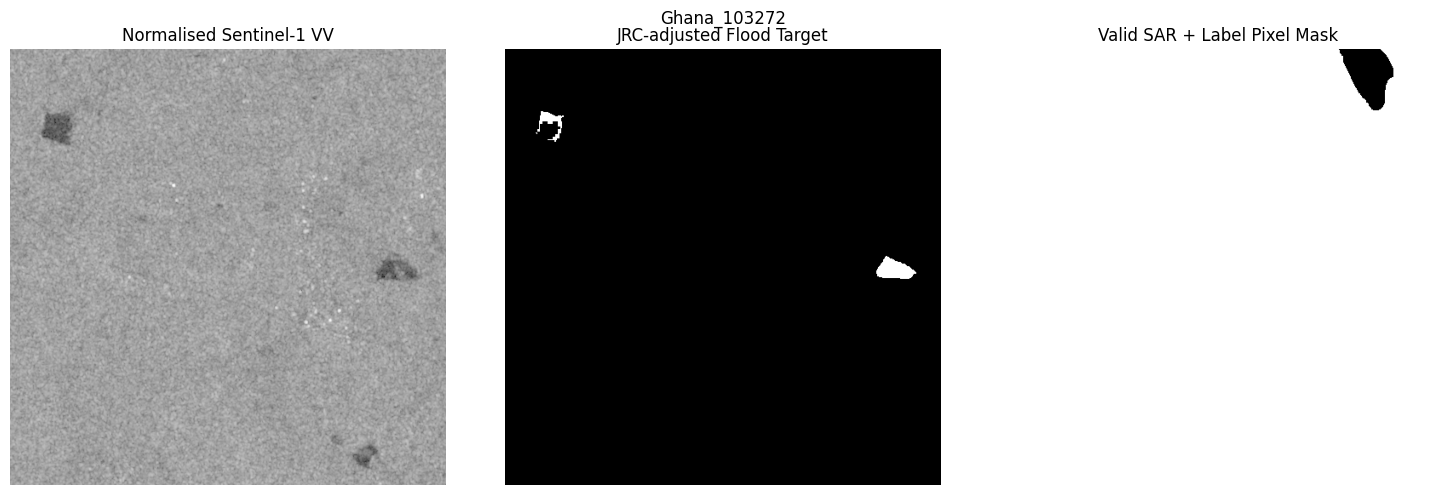

In [ ]:
# Vis. inspection of JRC flood target:

sample = train_dataset[0]
image = sample["image"].numpy()
target = sample["target"].squeeze(0).numpy()
valid_mask = sample["valid_mask"].squeeze(0).numpy()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# VV channel after normalisation
axes[0].imshow(image[0], cmap="gray")
axes[0].set_title("Normalised Sentinel-1 VV")
axes[0].axis("off")

# Ground truth
axes[1].imshow(target, cmap="gray")
axes[1].set_title("JRC-adjusted Flood Target")
axes[1].axis("off")

# Valid pixels
axes[2].imshow(valid_mask, cmap="gray")
axes[2].set_title("Valid SAR + Label Pixel Mask")
axes[2].axis("off")

plt.suptitle(sample["scene_id"])
plt.tight_layout()
plt.show()


-------------------
###### 5
## Section 5: U-Net Model
###### 5.1
### Section 5.1 - U-Net Architecture

In [ ]:
# U-Net model:

import torch.nn as nn


class DoubleConv(nn.Module):
    """
    Two consecutive 3x3 convolutions, each followed by
    batch normalisation and ReLU activation.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    """
    U-Net architecture for binary Sentinel-1 flood/water
    segmentation.

    Input:
        2 channels (VV and VH)

    Output:
        1 channel containing segmentation logits
    """

    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        self.pool = nn.MaxPool2d(kernel_size=2)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Final 1x1 convolution
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # IMPORTANT:
        # Returns the logits, not sigmoid probabilities. Sigmoid will be applied only when probabilities are required for prediction.
        return self.final_conv(d1)

In [25]:
# Instantiate U-Net:

unet = UNet(in_channels=2, out_channels=1).to(DEVICE)
print(unet)

UNet(
  (enc1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inpl

In [26]:
# Count U-Net parameters:
# (for reproducibility)

total_parameters = sum(parameter.numel() for parameter in unet.parameters())
trainable_parameters = sum(parameter.numel()for parameter in unet.parameters()if parameter.requires_grad)

print(f"Total parameters     : {total_parameters:,}")
print(f"Trainable parameters  : {trainable_parameters:,}")

Total parameters     : 31,037,057
Trainable parameters  : 31,037,057


--------------------
###### 5.2
### Section 5.2 - Model Checks
Here I want to establish that the model can correctly accept your (2, 512, 512) input and produce (1, 512, 512) output before beginning a full training run.

In [ ]:
# U-Net forward-pass smoke test:
# (I deliberately test with one sample rather than a whole batch first).

unet.eval()
test_input = images[:1].to(DEVICE)
with torch.no_grad(): test_output = unet(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)
print("Output dtype:", test_output.dtype)
print("Output range:", test_output.min().item(), "to", test_output.max().item())

Input shape : torch.Size([1, 2, 512, 512])
Output shape: torch.Size([1, 1, 512, 512])
Output dtype: torch.float32
Output range: -0.12422069907188416 to -0.035913363099098206


*(The output range does not need to be 0–1 because these are logits.)

Checking the Masked BCE + Dice loss because the invalid -1 pixels must not contribute to the loss.

In [ ]:
# Flood target masked BCE and Dice Loss:

class MaskedBCEDiceLoss(nn.Module):
    """
    Combined binary cross-entropy and Dice loss.

    Invalid pixels are excluded using the pre-supplied
    valid-pixel mask, which includes both LabelHand validity
    and Sentinel-1 SAR validity.
    """

    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()

        self.alpha = alpha
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss(reduction="none")

    def forward(self, logits, targets, valid_mask):

        # Binary cross-entropy:
        bce_loss = self.bce(logits, targets)
        valid_mask = valid_mask.float()
        bce_loss = (bce_loss * valid_mask).sum() / valid_mask.sum().clamp_min(1.0)

        # The Dice loss:
        probabilities = torch.sigmoid(logits)
        predictions = probabilities * valid_mask
        targets_valid = targets * valid_mask
        predictions_flat = predictions.view(predictions.shape[0], -1)
        targets_flat = targets_valid.view (targets_valid.shape[0], -1)
        intersection = (predictions_flat * targets_flat).sum(dim=1)
        denominator = (predictions_flat.sum(dim=1) + targets_flat.sum(dim=1))
        dice_score = ((2.0 * intersection + self.smooth) / (denominator + self.smooth))
        dice_loss = 1.0 - dice_score
        dice_loss = dice_loss.mean()

        # Combined loss:
        total_loss = (self.alpha * bce_loss + (1.0 - self.alpha) * dice_loss)

        return total_loss


In [29]:
# Testing masked BCE + Dice loss:

criterion = MaskedBCEDiceLoss(alpha=0.5).to(DEVICE)
test_target = targets[:1].to(DEVICE)
test_valid_mask = valid_masks[:1].to(DEVICE)
loss_value = criterion(test_output, test_target, test_valid_mask)

print("Test loss:", loss_value.item())
print("Loss is finite:", torch.isfinite(loss_value).item())

Test loss: 0.7954832315444946
Loss is finite: True


In [30]:
# Test one backpropagation step:
# (makes sure the complete optimisation pathway works).

unet.train()

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-4)
optimizer.zero_grad()

train_input = images[:1].to(DEVICE)
train_target = targets[:1].to(DEVICE)
train_valid_mask = valid_masks[:1].to(DEVICE)

output = unet(train_input)

loss = criterion(output, train_target, train_valid_mask)
loss.backward()

optimizer.step()

print("One optimisation step completed successfully.")
print("Loss:", loss.item())

One optimisation step completed successfully.
Loss: 0.7524468898773193


--------------------
###### 5.3
### Section 5.3 - U-Net training

In [31]:
# Clear MPS cache:

if DEVICE.type == "mps":
    torch.mps.empty_cache()

print("MPS cache cleared.")

MPS cache cleared.


In [32]:
# U-Net training configuration:

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 50
PATIENCE = 10
LOSS_ALPHA = 0.5

print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)
print("Maximum epochs:", MAX_EPOCHS)
print("Early stopping:", PATIENCE)
print("Loss alpha    :", LOSS_ALPHA)

Learning rate : 0.0001
Weight decay  : 0.0001
Maximum epochs: 50
Early stopping: 10
Loss alpha    : 0.5


In [33]:
# Initialising final U-Net training model:
# (Re-initialising the model so the earlier one-step test does not influence the actual training experiment).

unet = UNet(in_channels=2, out_channels=1).to(DEVICE)
criterion = MaskedBCEDiceLoss(alpha=LOSS_ALPHA).to(DEVICE)
optimizer = torch.optim.AdamW(unet.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print("U-Net, loss function and optimiser initialised.")

U-Net, loss function and optimiser initialised.


In [34]:
# Training function:

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    accumulation_steps=8
):
    """
    Trains the model for one complete epoch
    using gradient accumulation to save memory.

    Parameters
    ----------
    model : torch.nn.Module
        Segmentation model being trained.
    loader : DataLoader
        Training DataLoader.
    criterion : torch.nn.Module
        Loss function.
    optimizer : torch.optim.Optimizer
        Optimiser used to update model parameters.
    device : torch.device
        Training device.

    Returns
    -------
    float
        Mean training loss for the epoch.
    """

    model.train()

    running_loss = 0.0
    batch_count = 0

    optimizer.zero_grad()

    for batch_index, batch in enumerate(loader):

        images = batch["image"].to(device)
        targets = batch["target"].to(device)
        valid_masks = batch["valid_mask"].to(device)

        logits = model(images)

        loss = criterion(
            logits,
            targets,
            valid_masks)

        # Scale the loss so the accumulated gradient represents the mean across accumulation steps.
        scaled_loss = loss / accumulation_steps
        scaled_loss.backward()
        running_loss += loss.item()
        batch_count += 1

        # Update weights every accumulation_steps batches
        if (
            (batch_index + 1) % accumulation_steps == 0
            or (batch_index + 1) == len(loader)
        ):

            optimizer.step()
            optimizer.zero_grad()

    epoch_loss = running_loss / batch_count

    return epoch_loss

In [35]:
# Validation function:

def validate_one_epoch(model, loader, criterion, device):
    """
    Evaluates the model on the validation dataset.

    No gradients are calculated and model parameters
    are not updated.

    Parameters
    ----------
    model : torch.nn.Module
        Segmentation model being evaluated.
    loader : DataLoader
        Validation DataLoader.
    criterion : torch.nn.Module
        Loss function.
    device : torch.device
        Evaluation device.

    Returns
    -------
    float
        Mean validation loss for the epoch.
    """

    model.eval()
    running_loss = 0.0
    batch_count = 0

    with torch.no_grad():

        for batch in loader:

            images = batch["image"].to(device)
            targets = batch["target"].to(device)
            valid_masks = batch["valid_mask"].to(device)

            logits = model(images)

            loss = criterion(
                logits,
                targets,
                valid_masks)

            running_loss += loss.item()
            batch_count += 1

    epoch_loss = running_loss / batch_count

    return epoch_loss

This is now the real experiment. It will train for up to 50 epochs and stop early if validation loss doesn't improve for 10 consecutive epochs:

In [ ]:
# U-Net model training with added check point saving for every latest best epoch:

from copy import deepcopy

UNET_CHECKPOINT = MODEL_DIR / "unet_best.pt"
RESUME_UNET_FROM_CHECKPOINT = False

training_history = {"train_loss": [], "val_loss": []}

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0
start_epoch = 1

# Set RESUME_UNET_FROM_CHECKPOINT = True only when recovering an interrupted run.
if (
    RESUME_UNET_FROM_CHECKPOINT
    and UNET_CHECKPOINT.exists()
):

    checkpoint = torch.load(
        UNET_CHECKPOINT,
        map_location=DEVICE)

    unet.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    best_val_loss = checkpoint["best_val_loss"]
    best_model_state = deepcopy(unet.state_dict())
    training_history = checkpoint["training_history"]
    epochs_without_improvement = checkpoint["epochs_without_improvement"]
    start_epoch = checkpoint["epoch"] + 1

    print(f"Resuming U-Net from epoch "
        f"{checkpoint['epoch']}.")
    print(f"Best validation loss so far: "
        f"{best_val_loss:.6f}")

for epoch in range(start_epoch, MAX_EPOCHS + 1):

    train_loss = train_one_epoch(unet, train_loader, criterion,
        optimizer, DEVICE, accumulation_steps=ACCUMULATION_STEPS)

    val_loss = validate_one_epoch(unet, validation_loader, criterion, DEVICE)

    training_history["train_loss"].append(train_loss)
    training_history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_model_state = deepcopy(unet.state_dict())
        epochs_without_improvement = 0

        # Saves the best model immediately so a later interruption cannot discard the progress already achieved.
        if DEVICE.type == "mps":
            torch.mps.synchronize()

        torch.save(
            {
                "model_state_dict": unet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "best_epoch": epoch,
                "epoch": epoch,
                "epochs_without_improvement": (epochs_without_improvement),
                "training_history": training_history,

                # Preprocessing parameters
                "vv_mean": VV_MEAN,
                "vv_std": VV_STD,
                "vh_mean": VH_MEAN,
                "vh_std": VH_STD,

                # Training configuration
                "batch_size": BATCH_SIZE,
                "gradient_accumulation": ACCUMULATION_STEPS,
                "effective_batch_size": (BATCH_SIZE * ACCUMULATION_STEPS),
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "loss_alpha": LOSS_ALPHA,
                "patience": PATIENCE,
                "seed": SEED
            },
            UNET_CHECKPOINT)

        print("  -> New best validation loss")
        print("  -> Best U-Net checkpoint saved to:",
            UNET_CHECKPOINT)

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping triggered after "
            f"{epoch} epochs.")

        break

    # Releasing the unused cached MPS memory
    if DEVICE.type == "mps":
        torch.mps.empty_cache()

if best_model_state is not None:
    unet.load_state_dict(best_model_state)

print("\nTraining complete.")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Epochs completed: "
    f"{len(training_history['train_loss'])}")


Epoch 01/50 | Train Loss: 0.725931 | Val Loss: 0.734496
  -> New best validation loss
  -> Best U-Net checkpoint saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/unet_best.pt
Epoch 02/50 | Train Loss: 0.659520 | Val Loss: 0.680933
  -> New best validation loss
  -> Best U-Net checkpoint saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/unet_best.pt
Epoch 03/50 | Train Loss: 0.632536 | Val Loss: 0.672517
  -> New best validation loss
  -> Best U-Net checkpoint saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/unet_best.pt
Epoch 04/50 | Train Loss: 0.619655 | Val Loss: 0.643954
  -> New best validation loss
  -> Best U-Net checkpoint saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/unet_best.pt
Epoch 05/50 | Train Loss: 0.605529 |

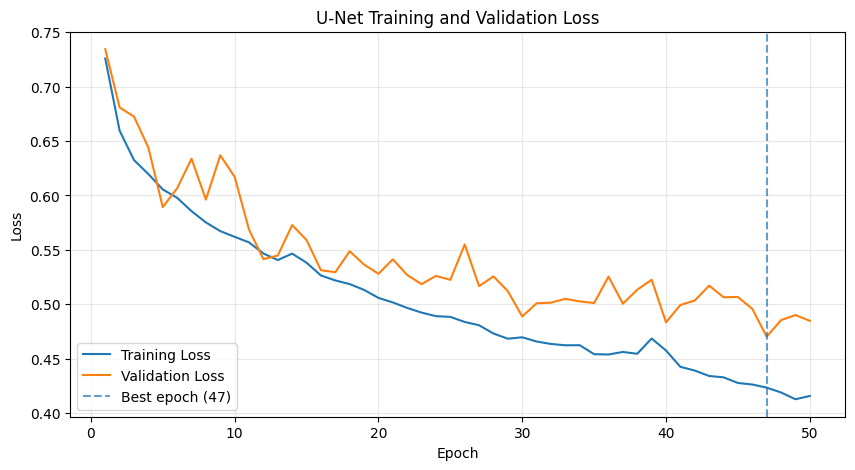

Epochs completed: 50
Best epoch: 47
Best validation loss: 0.470130


In [37]:
# U-Net training history:

epochs_completed = len(training_history["train_loss"])
best_epoch = int(np.argmin(training_history["val_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs_completed + 1), training_history["train_loss"], label="Training Loss")
plt.plot(range(1, epochs_completed + 1), training_history["val_loss"], label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("Epochs completed:", epochs_completed)
print("Best epoch:", best_epoch)
print(f"Best validation loss: {best_val_loss:.6f}")

In [ ]:
# Saving the best U-Net model:

# Restore best validation model
if best_model_state is not None:
    unet.load_state_dict(best_model_state)

torch.save(
    {
        "model_state_dict": unet.state_dict(),
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "epochs_completed": epochs_completed,
        "training_history": training_history,
        "vv_mean": VV_MEAN,
        "vv_std": VV_STD,
        "vh_mean": VH_MEAN,
        "vh_std": VH_STD,
        "batch_size": BATCH_SIZE,
        "gradient_accumulation": ACCUMULATION_STEPS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "loss_alpha": LOSS_ALPHA,
        "patience": PATIENCE,
        "seed": SEED
    },
    UNET_CHECKPOINT
)

print("U-Net checkpoint saved:")
print(UNET_CHECKPOINT)


U-Net checkpoint saved:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/unet_best.pt


--------------------
###### 5.4
### Section 5.4 - U-Net test evaluation

In [39]:
# Per-scene segmentation metrics:

def calculate_segmentation_metrics(
    prediction, target, valid_mask
):
    """
    Calculates IoU, F1, precision and recall for one scene.

    Invalid pixels are excluded using valid_mask.
    """

    prediction = prediction.astype(bool)
    target = target.astype(bool)
    valid_mask = valid_mask.astype(bool)

    prediction = prediction[valid_mask]
    target = target[valid_mask]

    tp = np.sum(prediction & target)
    fp = np.sum(prediction & ~target)
    tn = np.sum(~prediction & ~target)
    fn = np.sum(~prediction & target)

    iou_denominator = tp + fp + fn
    f1_denominator = 2 * tp + fp + fn
    precision_denominator = tp + fp
    recall_denominator = tp + fn

    iou = (
        tp / iou_denominator
        if iou_denominator > 0
        else np.nan)

    f1 = (
        2 * tp / f1_denominator
        if f1_denominator > 0
        else np.nan)

    precision = (
        tp / precision_denominator
        if precision_denominator > 0
        else np.nan)

    recall = (
        tp / recall_denominator
        if recall_denominator > 0
        else np.nan)

    return {
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn),
        "IoU": iou,
        "F1": f1,
        "Precision": precision,
        "Recall": recall}

In [ ]:
# JRC-adjusted flood extent calculation and function:


def calculate_flood_extent(scene_id):
    """
    Calculates the original LabelHand water extent and
    JRC-adjusted event-associated flood extent.

    Flood extent is calculated from the scene ground-truth masks
    independently of the model evaluation mask.
    """

    label_path = (LABEL_HAND_DIR / f"{scene_id}_LabelHand.tif")
    jrc_path = (JRC_WATER_HAND_DIR / f"{scene_id}_JRCWaterHand.tif")

    with rasterio.open(label_path) as src:
        label = src.read(1)

    with rasterio.open(jrc_path) as src:
        jrc = src.read(1)

    # Valid pixels are based on LabelHand as in the original extent definition.
    valid_mask = label != -1

    # Original LabelHand water
    water_mask = (label == 1) & valid_mask

    # Permanent water
    permanent_mask = (jrc == 1) & valid_mask

    # Event-associated (flood) water
    event_water = (label == 1) & (jrc == 0) & valid_mask

    valid_pixels = np.sum(valid_mask)
    water_pixels = np.sum(water_mask)
    permanent_pixels = np.sum(permanent_mask)
    event_water_pixels = np.sum(event_water)

    original_extent = (water_pixels / valid_pixels * 100
        if valid_pixels > 0
        else np.nan)

    adjusted_extent = (event_water_pixels / valid_pixels * 100
        if valid_pixels > 0
        else np.nan)

    return {
        "valid_pixels": int(valid_pixels),
        "water_pixels": int(water_pixels),
        "permanent_water_pixels": int(permanent_pixels),
        "event_water_pixels": int(event_water_pixels),
        "original_water_extent": original_extent,
        "flood_extent": adjusted_extent}


In [ ]:
# Evaluating the flood segmentation models performance:


def evaluate_model(model, loader, metadata,
    model_name, device, threshold=0.5
):
    """
    Evaluates a trained segmentation model scene-by-scene.

    Returns a DataFrame containing:
        - scene ID
        - flood event
        - flood extent
        - IoU
        - F1
        - precision
        - recall
        - confusion matrix counts
    """

    model.eval()
    metadata_lookup = (metadata.set_index("s1_id").to_dict("index"))
    results = []

    with torch.no_grad():

        for batch in loader:
            scene_id = batch["scene_id"][0]
            images = batch["image"].to(device)
            target = (batch["target"].squeeze(0).squeeze(0).cpu().numpy())
            valid_mask = (batch["valid_mask"].squeeze(0).squeeze(0).cpu().numpy())
            logits = model(images)
            probabilities = torch.sigmoid(logits)
            prediction = (probabilities >= threshold).squeeze(0).squeeze(0).cpu().numpy()

            # Flood segmentation metrics
            metrics = calculate_segmentation_metrics(prediction, target, valid_mask)
            # JRC-adjusted flood extent
            extent = calculate_flood_extent(scene_id)
            # Metadata
            scene_metadata = metadata_lookup.get(scene_id,{})

            results.append(
                {
                    "scene_id": scene_id,
                    "flood_event": scene_metadata.get(
                        "flood_event",
                        "Unknown"
                    ),
                    "model": model_name,

                    "flood_extent": extent[
                        "flood_extent"
                    ],

                    "original_water_extent": extent[
                        "original_water_extent"
                    ],

                    "valid_pixels": extent[
                        "valid_pixels"
                    ],

                    "water_pixels": extent[
                        "water_pixels"
                    ],

                    "permanent_water_pixels": extent[
                        "permanent_water_pixels"
                    ],

                    "event_water_pixels": extent[
                        "event_water_pixels"
                    ],

                    **metrics
                }
            )

            if device.type == "mps":
                torch.mps.empty_cache()

    return pd.DataFrame(results)


In [42]:
# U-Net principal test evaluation:

unet_test_results = evaluate_model(
    model=unet,
    loader=test_loader,
    metadata=test_metadata,
    model_name="U-Net",
    device=DEVICE,
    threshold=0.5)

print("U-Net test results shape:")
print(unet_test_results.shape)

display(unet_test_results.head())

U-Net test results shape:
(87, 17)


,scene_id,flood_event,model,flood_extent,original_water_extent,valid_pixels,water_pixels,permanent_water_pixels,event_water_pixels,TP,FP,TN,FN,IoU,F1,Precision,Recall
0,Ghana_313799,Ghana,U-Net,6.108466,6.108466,244464,14933,0,14933,279,3,229528,14654,0.018680,0.036674,0.989362,0.018683
1,Ghana_1078550,Ghana,U-Net,0.536728,0.536728,262144,1407,0,1407,59,15,260722,1348,0.041491,0.079676,0.797297,0.041933
2,Ghana_97059,Ghana,U-Net,0.000000,0.000000,27394,0,0,0,0,322,27072,0,0.000000,0.000000,0.000000,NaN
3,Ghana_359826,Ghana,U-Net,1.333618,1.333618,262144,3496,0,3496,1516,325,258323,1980,0.396755,0.568109,0.823466,0.433638
4,Ghana_319168,Ghana,U-Net,23.027665,23.027665,171624,39521,0,39521,12851,721,131382,26670,0.319343,0.484094,0.946876,0.325169


--------------------
###### 5.5
### Section 5.5 - U-Net Bolivia holdout evaluation

In [ ]:
# U-Net Bolivia holdout evaluation:

unet_bolivia_results = evaluate_model(
    model=unet,
    loader=bolivia_loader,
    metadata=bolivia_metadata_filtered,
    model_name="U-Net",
    device=DEVICE,
    threshold=0.5)

print("U-Net Bolivia results shape:")
print(unet_bolivia_results.shape)

display(unet_bolivia_results.head())

U-Net Bolivia results shape:
(14, 17)


,scene_id,flood_event,model,flood_extent,original_water_extent,valid_pixels,water_pixels,permanent_water_pixels,event_water_pixels,TP,FP,TN,FN,IoU,F1,Precision,Recall
0,Bolivia_129334,Bolivia,U-Net,64.188399,65.867863,237814,156643,4152,152649,18512,3073,81919,133561,0.119320,0.213201,0.857633,0.121731
1,Bolivia_195474,Bolivia,U-Net,0.593491,0.593491,261335,1551,0,1551,0,0,259784,1551,0.000000,0.000000,NaN,0.000000
2,Bolivia_23014,Bolivia,U-Net,0.206703,3.713976,209479,7780,7748,433,196,2376,180186,237,0.069776,0.130449,0.076205,0.452656
3,Bolivia_233925,Bolivia,U-Net,0.000664,0.000664,150537,1,0,1,0,1109,145184,1,0.000000,0.000000,0.000000,0.000000
4,Bolivia_242570,Bolivia,U-Net,15.581145,15.581145,175507,27346,0,27346,590,284,147877,26756,0.021354,0.041814,0.675057,0.021575


--------------------
###### 5.6
### Section 5.6 - U-Net Results

In [ ]:
# Save U-Net evaluation results:

UNET_TEST_RESULTS_FILE = (RESULTS_TABLE_DIR / "unet_test_results.csv")
UNET_BOLIVIA_RESULTS_FILE = (RESULTS_TABLE_DIR / "unet_bolivia_results.csv")

unet_test_results.to_csv(UNET_TEST_RESULTS_FILE, index=False)
unet_bolivia_results.to_csv(UNET_BOLIVIA_RESULTS_FILE, index=False)

print("Saved:")
print(UNET_TEST_RESULTS_FILE)
print(UNET_BOLIVIA_RESULTS_FILE)


Saved:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables/unet_test_results.csv
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables/unet_bolivia_results.csv


In [45]:
# U-Net test summary:
print("U-Net principal test summary")
print("--------------------------------")
print(f"Mean IoU      : "
    f"{unet_test_results['IoU'].mean():.4f}")
print(f"Mean F1       : "
    f"{unet_test_results['F1'].mean():.4f}")
print(f"Mean Precision: "
    f"{unet_test_results['Precision'].mean():.4f}")
print(f"Mean Recall   : "
    f"{unet_test_results['Recall'].mean():.4f}")
print(f"Mean JRC-adjusted flood extent: "
    f"{unet_test_results['flood_extent'].mean():.4f}%")
print('' \
'')
# U-Net Bolivia holdout summary:
print("U-Net Bolivia holdout summary")
print("--------------------------------")
print(f"Mean IoU      : "
    f"{unet_bolivia_results['IoU'].mean():.4f}")
print(f"Mean F1       : "
    f"{unet_bolivia_results['F1'].mean():.4f}")
print(f"Mean Precision: "
    f"{unet_bolivia_results['Precision'].mean():.4f}")
print(f"Mean Recall   : "
    f"{unet_bolivia_results['Recall'].mean():.4f}")
print(f"Mean JRC-adjusted flood extent: "
    f"{unet_bolivia_results['flood_extent'].mean():.4f}%")

U-Net principal test summary
--------------------------------
Mean IoU      : 0.2338
Mean F1       : 0.3385
Mean Precision: 0.4855
Mean Recall   : 0.4101
Mean JRC-adjusted flood extent: 7.9583%

U-Net Bolivia holdout summary
--------------------------------
Mean IoU      : 0.0687
Mean F1       : 0.1204
Mean Precision: 0.5019
Mean Recall   : 0.1162
Mean JRC-adjusted flood extent: 14.0733%


In [46]:
# Releasing the U-Net resources before training SegFormer so it can process faster:

import gc

# Remove large objects from memory if they exist
variables_to_delete = [
    "unet",
    "optimizer",
    "criterion",
    "best_model_state",
    "images",
    "targets",
    "valid_masks",
    "batch",
    "test_input",
    "test_output",
    "train_input",
    "train_target",
    "train_valid_mask",
    "output",
    "loss"
]

for variable_name in variables_to_delete:
    if variable_name in globals():
        del globals()[variable_name]

# Python garbage collection
gc.collect()

# Release unused cached MPS memory
if DEVICE.type == "mps":
    torch.mps.empty_cache()

print("U-Net objects released.")
print("Unused MPS cache cleared.")

U-Net objects released.
Unused MPS cache cleared.


-------------------
###### 6
## Section 6: SegFormer-B0 Model
###### 6.1
### Section 6.1 - SegFormer-B0 Architecture

In [47]:
# SegFormer imports:

import time
import torch.nn.functional as F
from transformers import (SegformerConfig, SegformerForSemanticSegmentation)

print("SegFormer libraries imported successfully.")

SegFormer libraries imported successfully.


Keeping the architectural configuration consistent with B0 while adapting only the input channel count from the standard 3-channel configuration to my two Sentinel-1 channels.

In [48]:
# SegFormer-B0 model:

class SegFormerB0Binary(nn.Module):
    """
    SegFormer-B0 configured for binary segmentation
    using two Sentinel-1 SAR input channels.

    Input:
        2 channels (VV and VH)

    Output:
        1 channel of segmentation logits
    """

    def __init__(self):

        super().__init__()

        config = SegformerConfig(
            num_channels=2,
            num_labels=1,

            # The SegFormer-B0 configuration:
            num_encoder_blocks=4,
            depths=[2, 2, 2, 2],
            sr_ratios=[8, 4, 2, 1],
            hidden_sizes=[32, 64, 160, 256],
            patch_sizes=[7, 3, 3, 3],
            strides=[4, 2, 2, 2],
            num_attention_heads=[1, 2, 5, 8],
            mlp_ratios=[4, 4, 4, 4],
            hidden_act="gelu",
            hidden_dropout_prob=0.0,
            attention_probs_dropout_prob=0.0,
            classifier_dropout_prob=0.1,
            drop_path_rate=0.1,
            decoder_hidden_size=256
        )

        self.model = (SegformerForSemanticSegmentation(config))

    def forward(self, x):

        outputs = self.model(pixel_values=x)
        logits = outputs.logits
        # SegFormer produces lower-resolution segmentation logits, so resizing them to the original 512 x 512 resolution:
        logits = F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

        return logits

--------------------
###### 6.2
### Section 6.2 - SegFormer training configuration

The important thing here is that I am not changing the experimental training conditions. I am only determining how many samples can physically be processed simultaneously.

In [62]:
# SegFormer training configuration:

SEGFORMER_MAX_EPOCHS = 50
SEGFORMER_PATIENCE = 10
SEGFORMER_LEARNING_RATE = 1e-4
SEGFORMER_WEIGHT_DECAY = 1e-4
SEGFORMER_LOSS_ALPHA = 0.5

# Candidate physical batch sizes. All will eventually use an effective batch size of 8.
SEGFORMER_CANDIDATE_BATCH_SIZES = [1, 2, 4, 8]
EFFECTIVE_BATCH_SIZE = 8

print("Maximum epochs :", SEGFORMER_MAX_EPOCHS)
print("Patience       :", SEGFORMER_PATIENCE)
print("Learning rate  :", SEGFORMER_LEARNING_RATE)
print("Weight decay   :", SEGFORMER_WEIGHT_DECAY)
print("Loss alpha     :", SEGFORMER_LOSS_ALPHA)
print(
    "Candidate batch sizes:",
    SEGFORMER_CANDIDATE_BATCH_SIZES)
print("Effective batch size:", EFFECTIVE_BATCH_SIZE)

Maximum epochs : 50
Patience       : 10
Learning rate  : 0.0001
Weight decay   : 0.0001
Loss alpha     : 0.5
Candidate batch sizes: [1, 2, 4, 8]
Effective batch size: 8


In [63]:
# Benchmark SegFormer batch sizes:

def benchmark_segformer_batch_size(batch_size):
    """
    Testing whether SegFormer-B0 can complete one complete
    training step at a specified physical batch size.

    The test includes:
        - model creation
        - forward pass
        - BCE + Dice loss
        - backward pass
        - AdamW update

    This is used only to determine the largest stable
    physical batch size for the available MPS memory.
    """

    print("\n" + "=" * 60)
    print(f"Testing SegFormer batch size: {batch_size}")
    print("=" * 60)

    # Cleaning any previous MPS allocations
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    model = None
    optimizer = None
    criterion = None
    try:

        #  fresh model:
        model = SegFormerB0Binary().to(DEVICE)
        criterion = MaskedBCEDiceLoss(alpha=SEGFORMER_LOSS_ALPHA).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=SEGFORMER_LEARNING_RATE, weight_decay=SEGFORMER_WEIGHT_DECAY)

        # Creating a temporary loader
        benchmark_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
        batch = next(iter(benchmark_loader))
        images = batch["image"].to(DEVICE)
        targets = batch["target"].to(DEVICE)
        valid_masks = batch["valid_mask"].to(DEVICE)

        # Training step
        model.train()
        optimizer.zero_grad()
        if DEVICE.type == "mps":
            torch.mps.synchronize()
        start_time = time.perf_counter()
        logits = model(images)
        loss = criterion(logits, targets, valid_masks)
        loss.backward()
        optimizer.step()
        if DEVICE.type == "mps":
            torch.mps.synchronize()
        elapsed = time.perf_counter() - start_time

        # Memory info
        if DEVICE.type == "mps":
            driver_memory_gb = (torch.mps.driver_allocated_memory() / (1024 ** 3))

        else:
            driver_memory_gb = np.nan

        print("SUCCESS")
        print(f"Input shape : {tuple(images.shape)}")
        print(f"Output shape: {tuple(logits.shape)}")
        print(f"Loss        : {loss.item():.6f}")
        print(f"Step time   : {elapsed:.2f} seconds")

        if DEVICE.type == "mps":
            print(f"MPS driver memory: "
                f"{driver_memory_gb:.2f} GB")

        result = {
            "batch_size": batch_size,
            "effective_batch_size": EFFECTIVE_BATCH_SIZE,
            "status": "SUCCESS",
            "step_time_seconds": elapsed,
            "loss": loss.item(),
            "mps_memory_gb": driver_memory_gb}

    except RuntimeError as error:
        error_message = str(error)

        if ("MPS backend out of memory"
            in error_message
        ):
            print("FAILED: MPS OUT OF MEMORY")

            result = {
                "batch_size": batch_size,
                "effective_batch_size": EFFECTIVE_BATCH_SIZE,
                "status": "MPS_OOM",
                "step_time_seconds": np.nan,
                "loss": np.nan,
                "mps_memory_gb": np.nan}

        else:
            print("FAILED:")
            print(error_message)

            result = {
                "batch_size": batch_size,
                "effective_batch_size": EFFECTIVE_BATCH_SIZE,
                "status": "ERROR",
                "step_time_seconds": np.nan,
                "loss": np.nan,
                "mps_memory_gb": np.nan}

    finally:

        # Freeing the benchmark model before next test

        if model is not None:
            del model
        if optimizer is not None:
            del optimizer
        if criterion is not None:
            del criterion
        if "benchmark_loader" in locals():
            del benchmark_loader
        if "batch" in locals():
            del batch
        if "images" in locals():
            del images
        if "targets" in locals():
            del targets
        if "valid_masks" in locals():
            del valid_masks
        if "logits" in locals():
            del logits
        if "loss" in locals():
            del loss

        gc.collect()

        if DEVICE.type == "mps":
            torch.mps.empty_cache()

    return result

In [64]:
# Test candidate SegFormer batch sizes:

segformer_batch_results = []

for batch_size in SEGFORMER_CANDIDATE_BATCH_SIZES:

    result = benchmark_segformer_batch_size(batch_size)
    segformer_batch_results.append(result)

segformer_batch_results = pd.DataFrame(segformer_batch_results)

display(segformer_batch_results)


Testing SegFormer batch size: 1
SUCCESS
Input shape : (1, 2, 512, 512)
Output shape: (1, 1, 512, 512)
Loss        : 0.843302
Step time   : 0.69 seconds
MPS driver memory: 1.18 GB

Testing SegFormer batch size: 2
SUCCESS
Input shape : (2, 2, 512, 512)
Output shape: (2, 1, 512, 512)
Loss        : 0.838710
Step time   : 0.69 seconds
MPS driver memory: 2.22 GB

Testing SegFormer batch size: 4
SUCCESS
Input shape : (4, 2, 512, 512)
Output shape: (4, 1, 512, 512)
Loss        : 0.859408
Step time   : 1.19 seconds
MPS driver memory: 3.28 GB

Testing SegFormer batch size: 8
SUCCESS
Input shape : (8, 2, 512, 512)
Output shape: (8, 1, 512, 512)
Loss        : 0.792340
Step time   : 2.66 seconds
MPS driver memory: 5.29 GB


,batch_size,effective_batch_size,status,step_time_seconds,loss,mps_memory_gb
0,1,8,SUCCESS,0.692247,0.843302,1.176300
1,2,8,SUCCESS,0.686420,0.838710,2.215744
2,4,8,SUCCESS,1.187041,0.859408,3.278244
3,8,8,SUCCESS,2.664089,0.792340,5.293869


As is possibe to see, the fastest batch size to train SegFormer-B0 with is 4 with gradient accumulation of 2. So batch 4 is actually faster than batch 8, despite requiring two forward/backward passes, because the measured batch-4 processing is much more efficient.

In [65]:
# Now Cleaning up SegFormer benchmark objects

import gc

for variable_name in [
    "model",
    "optimizer",
    "criterion",
    "benchmark_loader",
    "batch",
    "images",
    "targets",
    "valid_masks",
    "logits",
    "loss"
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if DEVICE.type == "mps":
    torch.mps.empty_cache()

print("SegFormer benchmark memory cleared.")

SegFormer benchmark memory cleared.


In [66]:
# SegFormer final training configuration:

SEGFORMER_BATCH_SIZE = 4
SEGFORMER_ACCUMULATION_STEPS = 2
SEGFORMER_MAX_EPOCHS = 50
SEGFORMER_PATIENCE = 10
SEGFORMER_LEARNING_RATE = 1e-4
SEGFORMER_WEIGHT_DECAY = 1e-4
SEGFORMER_LOSS_ALPHA = 0.5

print("Physical batch size :", SEGFORMER_BATCH_SIZE)
print("Gradient accumulation:",
      SEGFORMER_ACCUMULATION_STEPS)
print(
    "Effective batch size:",
    SEGFORMER_BATCH_SIZE *
    SEGFORMER_ACCUMULATION_STEPS)

Physical batch size : 4
Gradient accumulation: 2
Effective batch size: 8


In [ ]:
# Segformer-B0 data loaders:

segformer_train_loader = DataLoader(
    train_dataset,
    batch_size=SEGFORMER_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    persistent_workers=PERSISTENT_WORKERS)

segformer_validation_loader = DataLoader(
    validation_dataset,
    batch_size=SEGFORMER_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    persistent_workers=PERSISTENT_WORKERS)

print("Training batches:", len(segformer_train_loader))
print("Validation batches:", len(segformer_validation_loader))


Training batches: 62
Validation batches: 22


In [68]:
# Initialise final SegFormer-B0

segformer = SegFormerB0Binary().to(DEVICE)
segformer_criterion = MaskedBCEDiceLoss(alpha=SEGFORMER_LOSS_ALPHA).to(DEVICE)
segformer_optimizer = torch.optim.AdamW(segformer.parameters(), lr=SEGFORMER_LEARNING_RATE, weight_decay=SEGFORMER_WEIGHT_DECAY)

print("SegFormer-B0 initialised for final training.")

SegFormer-B0 initialised for final training.


----------------
###### 6.3
### Section 6.3 - SegFormer-B0 Model Training

In [69]:
# Training my SegFormer-B0 Model:

from copy import deepcopy

segformer_history = {"train_loss": [], "val_loss": []}
best_segformer_val_loss = float("inf")
best_segformer_state = None
segformer_epochs_without_improvement = 0
training_start = time.perf_counter()

for epoch in range(1, SEGFORMER_MAX_EPOCHS + 1):

    epoch_start = time.perf_counter()

    # Training:
    train_loss = train_one_epoch(
        segformer, segformer_train_loader,
        segformer_criterion, segformer_optimizer,
        DEVICE, accumulation_steps=SEGFORMER_ACCUMULATION_STEPS)

    # Validation:
    val_loss = validate_one_epoch(
        segformer, segformer_validation_loader,
        segformer_criterion, DEVICE)

    # Store the history:
    segformer_history["train_loss"].append(train_loss)
    segformer_history["val_loss"].append(val_loss)
    epoch_time = time.perf_counter() - epoch_start

    print(f"Epoch {epoch:02d}/{SEGFORMER_MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Time: {epoch_time / 60:.2f} min")

    # Save the best validation model
    if val_loss < best_segformer_val_loss:

        best_segformer_val_loss = val_loss
        best_segformer_state = deepcopy(segformer.state_dict())
        segformer_epochs_without_improvement = 0

        print("  -> New best validation loss")

        # !!! CHANGED: CONTINUOUSLY SAVE BEST SEGFORMER CHECKPOINT !!!
        SEGFORMER_CHECKPOINT = (
            MODEL_DIR / "segformer_b0_best.pt"
        )

        torch.save(
            {
                "model_state_dict": (
                    segformer.state_dict()
                ),
                "optimizer_state_dict": (
                    segformer_optimizer.state_dict()
                ),
                "best_val_loss": (
                    best_segformer_val_loss
                ),
                "best_epoch": epoch,
                "epochs_completed": epoch,
                "training_history": (
                    segformer_history
                ),
                "epochs_without_improvement": (
                    segformer_epochs_without_improvement
                ),

                # Preprocessing parameters
                "vv_mean": VV_MEAN,
                "vv_std": VV_STD,
                "vh_mean": VH_MEAN,
                "vh_std": VH_STD,

                # Training configuration
                "batch_size": SEGFORMER_BATCH_SIZE,
                "gradient_accumulation": (
                    SEGFORMER_ACCUMULATION_STEPS
                ),
                "effective_batch_size": (
                    SEGFORMER_BATCH_SIZE
                    * SEGFORMER_ACCUMULATION_STEPS
                ),
                "learning_rate": (
                    SEGFORMER_LEARNING_RATE
                ),
                "weight_decay": (
                    SEGFORMER_WEIGHT_DECAY
                ),
                "loss_alpha": SEGFORMER_LOSS_ALPHA,
                "patience": SEGFORMER_PATIENCE,
                "seed": SEED
            },
            SEGFORMER_CHECKPOINT
        )

        print(
            "  -> Best SegFormer checkpoint saved to:",
            SEGFORMER_CHECKPOINT
        )

    else:

        segformer_epochs_without_improvement += 1

    # Early stopping:
    if (segformer_epochs_without_improvement >= SEGFORMER_PATIENCE
    ):

        print(f"\nEarly stopping triggered after "
            f"{epoch} epochs.")

        break

    # clear unused MPS cache:
    if DEVICE.type == "mps":
        torch.mps.empty_cache()

# Restore best validation model
if best_segformer_state is not None:
    segformer.load_state_dict(best_segformer_state)

total_training_time = (time.perf_counter() - training_start)
best_segformer_epoch = int(np.argmin(segformer_history["val_loss"]) + 1)
epochs_completed = len(segformer_history["train_loss"])

print("\nSegFormer training complete.")
print("Epochs completed:", epochs_completed)
print("Best epoch:", best_segformer_epoch)
print(f"Best validation loss: "
    f"{best_segformer_val_loss:.6f}")
print(f"Total training time: "
    f"{total_training_time / 60:.2f} minutes")

Epoch 01/50 | Train Loss: 0.773826 | Val Loss: 0.731714 | Time: 1.30 min
  -> New best validation loss
  -> Best SegFormer checkpoint saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/segformer_b0_best.pt
Epoch 02/50 | Train Loss: 0.709140 | Val Loss: 0.658128 | Time: 1.27 min
  -> New best validation loss
  -> Best SegFormer checkpoint saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/segformer_b0_best.pt
Epoch 03/50 | Train Loss: 0.667599 | Val Loss: 0.617616 | Time: 1.28 min
  -> New best validation loss
  -> Best SegFormer checkpoint saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/segformer_b0_best.pt
Epoch 04/50 | Train Loss: 0.637079 | Val Loss: 0.599416 | Time: 1.29 min
  -> New best validation loss
  -> Best SegFormer checkpoint saved to: /Users/archiewilliamhulse/Desktop/Msc Data Sci

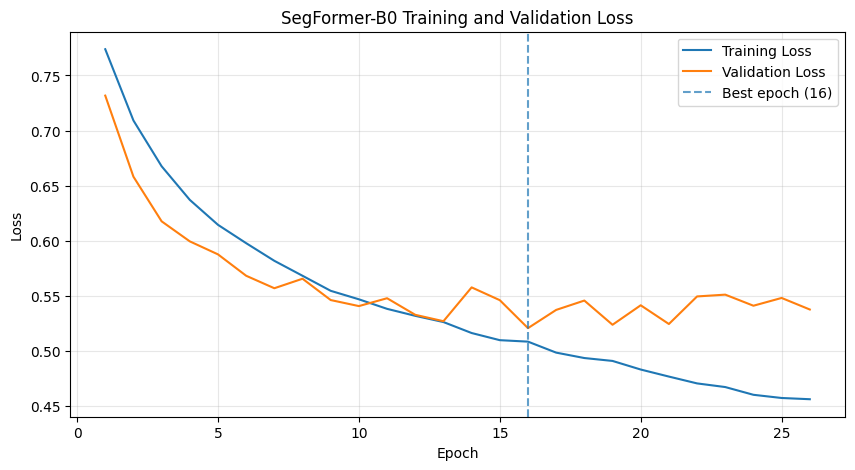

Epochs completed: 26
Best epoch: 16
Best validation loss: 0.520662


In [70]:
# SegFormer-B0 Model training history:

epochs_completed = len(segformer_history["train_loss"])
best_epoch = int(np.argmin(segformer_history["val_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs_completed + 1), segformer_history["train_loss"],label="Training Loss")
plt.plot(range(1, epochs_completed + 1), segformer_history["val_loss"], label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SegFormer-B0 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Epochs completed:", epochs_completed)
print("Best epoch:", best_epoch)
print(f"Best validation loss: "
    f"{best_segformer_val_loss:.6f}")

In [71]:
# Saving the best SegFormer model:

SEGFORMER_CHECKPOINT = (MODEL_DIR / "segformer_b0_best.pt")

if best_segformer_state is not None:
    segformer.load_state_dict(best_segformer_state)

torch.save(
    {
        "model_state_dict": (segformer.state_dict()),
        "best_val_loss": (best_segformer_val_loss),
        "best_epoch": best_segformer_epoch,
        "epochs_completed": epochs_completed,
        "training_history": (segformer_history),

        # Preprocessing parameters
        "vv_mean": VV_MEAN,
        "vv_std": VV_STD,
        "vh_mean": VH_MEAN,
        "vh_std": VH_STD,

        # Training configuration
        "batch_size": SEGFORMER_BATCH_SIZE,
        "gradient_accumulation": (SEGFORMER_ACCUMULATION_STEPS),
        "effective_batch_size": (SEGFORMER_BATCH_SIZE * SEGFORMER_ACCUMULATION_STEPS),
        "learning_rate": (SEGFORMER_LEARNING_RATE),
        "weight_decay": (SEGFORMER_WEIGHT_DECAY),
        "loss_alpha": SEGFORMER_LOSS_ALPHA,
        "patience": SEGFORMER_PATIENCE,
        "seed": SEED
    },
    SEGFORMER_CHECKPOINT)

print("SegFormer checkpoint saved:")
print(SEGFORMER_CHECKPOINT)


SegFormer checkpoint saved:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models/segformer_b0_best.pt


--------------------
###### 6.4
### Section 6.4 - SegFormer-B0 Test Evaluation

In [72]:
# SegFormer principal test evaluation:

segformer_test_results = evaluate_model(
    model=segformer,
    loader=test_loader,
    metadata=test_metadata,
    model_name="SegFormer-B0",
    device=DEVICE,
    threshold=0.5)

print("SegFormer test results shape:")
print(segformer_test_results.shape)

display(segformer_test_results.head())

SegFormer test results shape:
(87, 17)


,scene_id,flood_event,model,flood_extent,original_water_extent,valid_pixels,water_pixels,permanent_water_pixels,event_water_pixels,TP,FP,TN,FN,IoU,F1,Precision,Recall
0,Ghana_313799,Ghana,SegFormer-B0,6.108466,6.108466,244464,14933,0,14933,643,0,229531,14290,0.043059,0.082563,1.000000,0.043059
1,Ghana_1078550,Ghana,SegFormer-B0,0.536728,0.536728,262144,1407,0,1407,0,0,260737,1407,0.000000,0.000000,NaN,0.000000
2,Ghana_97059,Ghana,SegFormer-B0,0.000000,0.000000,27394,0,0,0,0,251,27143,0,0.000000,0.000000,0.000000,NaN
3,Ghana_359826,Ghana,SegFormer-B0,1.333618,1.333618,262144,3496,0,3496,940,71,258577,2556,0.263527,0.417129,0.929773,0.268879
4,Ghana_319168,Ghana,SegFormer-B0,23.027665,23.027665,171624,39521,0,39521,7100,876,131227,32421,0.175756,0.298966,0.890171,0.179651


--------------------
###### 6.5
### Section 6.5 - SegFormer-B0 Bolivia Holdout Evaluation

In [73]:
# SegFormer Bolivia holdout evaluation:

segformer_bolivia_results = evaluate_model(
    model=segformer,
    loader=bolivia_loader,
    metadata=bolivia_metadata,
    model_name="SegFormer-B0",
    device=DEVICE,
    threshold=0.5)

print("SegFormer Bolivia results shape:")
print(segformer_bolivia_results.shape)

display(segformer_bolivia_results.head())

SegFormer Bolivia results shape:
(14, 17)


,scene_id,flood_event,model,flood_extent,original_water_extent,valid_pixels,water_pixels,permanent_water_pixels,event_water_pixels,TP,FP,TN,FN,IoU,F1,Precision,Recall
0,Bolivia_129334,Bolivia,SegFormer-B0,64.188399,65.867863,237814,156643,4152,152649,68164,2658,82334,83909,0.440532,0.611624,0.962469,0.448232
1,Bolivia_195474,Bolivia,SegFormer-B0,0.593491,0.593491,261335,1551,0,1551,20,690,259094,1531,0.008925,0.017691,0.028169,0.012895
2,Bolivia_23014,Bolivia,SegFormer-B0,0.206703,3.713976,209479,7780,7748,433,3,5379,177183,430,0.000516,0.001032,0.000557,0.006928
3,Bolivia_233925,Bolivia,SegFormer-B0,0.000664,0.000664,150537,1,0,1,0,284,146009,1,0.000000,0.000000,0.000000,0.000000
4,Bolivia_242570,Bolivia,SegFormer-B0,15.581145,15.581145,175507,27346,0,27346,10714,11325,136836,16632,0.277055,0.433897,0.486138,0.391794


--------------------
###### 6.6
### Section 6.6 - SegFormer-B0 Results

In [74]:
# Saving the SegFormer-B0 model results:

SEGFORMER_TEST_RESULTS_FILE = (RESULTS_TABLE_DIR / "segformer_test_results.csv")
SEGFORMER_BOLIVIA_RESULTS_FILE = (RESULTS_TABLE_DIR / "segformer_bolivia_results.csv")

segformer_test_results.to_csv(SEGFORMER_TEST_RESULTS_FILE, index=False)
segformer_bolivia_results.to_csv(SEGFORMER_BOLIVIA_RESULTS_FILE, index=False)

print("Saved:")
print(SEGFORMER_TEST_RESULTS_FILE)
print(SEGFORMER_BOLIVIA_RESULTS_FILE)

Saved:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables/segformer_test_results.csv
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables/segformer_bolivia_results.csv


In [75]:
# SegFormer principal test summary:

print("SegFormer-B0 principal test summary")
print("------------------------------------")
print(f"Mean IoU      : "
    f"{segformer_test_results['IoU'].mean():.4f}")
print(f"Mean F1       : "
    f"{segformer_test_results['F1'].mean():.4f}")
print(f"Mean Precision: "
    f"{segformer_test_results['Precision'].mean():.4f}")
print(f"Mean Recall   : "
    f"{segformer_test_results['Recall'].mean():.4f}")
print(f"Mean JRC-adjusted flood extent: "
    f"{segformer_test_results['flood_extent'].mean():.4f}%")

print('' \
'')

print("SegFormer-B0 Bolivia holdout summary")
print("------------------------------------")
print(f"Mean IoU      : "
    f"{segformer_bolivia_results['IoU'].mean():.4f}")
print(f"Mean F1       : "
    f"{segformer_bolivia_results['F1'].mean():.4f}")
print(f"Mean Precision: "
    f"{segformer_bolivia_results['Precision'].mean():.4f}")
print(f"Mean Recall   : "
    f"{segformer_bolivia_results['Recall'].mean():.4f}")
print(f"Mean JRC-adjusted flood extent: "
    f"{segformer_bolivia_results['flood_extent'].mean():.4f}%")

SegFormer-B0 principal test summary
------------------------------------
Mean IoU      : 0.1202
Mean F1       : 0.1891
Mean Precision: 0.3259
Mean Recall   : 0.1979
Mean JRC-adjusted flood extent: 7.9583%

SegFormer-B0 Bolivia holdout summary
------------------------------------
Mean IoU      : 0.2006
Mean F1       : 0.2899
Mean Precision: 0.4348
Mean Recall   : 0.2616
Mean JRC-adjusted flood extent: 14.0733%
